# 13b — Extended Merton Climate Model and Asset-Shock Analogues

Blasberg (2024)'s climate-extended Merton model, where the firm's
discount/growth factor `delta(t)` is itself a Brownian motion
correlated with the asset value (a way of encoding a climate-driven
drag on firm value that is itself uncertain and correlated with the
underlying business), plus two related plain-Merton exercises
quantifying an instantaneous climate-driven asset-value haircut.

**Implementation note:** `e0_extended_merton_model`,
`b0_extended_merton_model`, and `pd_extended_merton_model` aren't
available as ready-made implementations elsewhere in this project, so
they were built here as
`quanttoolbox.credit.structural.{e0,b0,pd}_extended_merton_model`. The
first section below is itself a self-verification suite for these
three functions, and every one of its checks passes to essentially
machine precision.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from quanttoolbox.credit.structural import (
    e0_extended_merton_model, b0_extended_merton_model, pd_extended_merton_model,
)

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"

plt.rcParams["figure.dpi"] = 100


## 1. Self-verification: balance-sheet identity, standard-Merton recovery, monotonicity

Three checks on `e0_extended_merton_model`/`b0_extended_merton_model`/
`pd_extended_merton_model`, reproduced here as printed PASS/FAIL
results:
1. Balance-sheet identity `E0 + B0 = A0 * exp(-delta0'*T)`.
2. Recovery of the classical Black-Scholes-Merton formulas when
   `delta0 = mu_delta = sigma_delta = 0`.
3. Monotonicity of PD in the climate drift `mu_delta`.


In [2]:
def check(cond):
    return "PASS" if cond else "FAIL"


A0, D, r, mu_A = 100, 80, 0.03, 0.07
delta0, mu_delta, sigma_A, sigma_delta, rho, T = 0.01, 0.005, 0.20, 0.04, -0.30, 5

E0 = e0_extended_merton_model(A0, D, r, mu_A, delta0, mu_delta, sigma_A, sigma_delta, rho, T)
B0 = b0_extended_merton_model(A0, D, r, mu_A, delta0, mu_delta, sigma_A, sigma_delta, rho, T)
PD = pd_extended_merton_model(A0, D, r, mu_A, delta0, mu_delta, sigma_A, sigma_delta, rho, T)

print("=== Extended Merton model - sanity checks ===\n")
print("Base parameters:")
print(f"  E0  = {E0:.6f}")
print(f"  B0  = {B0:.6f}")
print(f"  PD  = {PD:.6f}")


=== Extended Merton model - sanity checks ===

Base parameters:
  E0  = 34.404728
  B0  = 60.797517
  PD  = 0.264022


In [3]:
# Test 1: balance-sheet identity
sigma_A_prime = np.sqrt(sigma_A**2 - rho * sigma_A * sigma_delta * T + (1 / 3) * sigma_delta**2 * T**2)
delta0_prime = delta0 + 0.5 * mu_delta * T + 0.5 * rho * sigma_A * sigma_delta * T - (1 / 6) * sigma_delta**2 * T**2
rhs = A0 * np.exp(-delta0_prime * T)

err1 = abs(E0 + B0 - rhs)
print("Test 1 - Balance-sheet identity  E0 + B0 = A0*exp(-delta0'*T):")
print(f"  E0 + B0            = {E0 + B0:.6f}")
print(f"  A0*exp(-delta0'*T) = {rhs:.6f}")
print(f"  Error              = {err1:.2e}  {check(err1 < 1e-10)}")


Test 1 - Balance-sheet identity  E0 + B0 = A0*exp(-delta0'*T):
  E0 + B0            = 95.202245
  A0*exp(-delta0'*T) = 95.202245
  Error              = 0.00e+00  PASS


In [4]:
# Test 2: standard Merton recovery (delta0 = mu_delta = sigma_delta = 0)
E0_ext = e0_extended_merton_model(A0, D, r, mu_A, 0, 0, sigma_A, 0, 0, T)
B0_ext = b0_extended_merton_model(A0, D, r, mu_A, 0, 0, sigma_A, 0, 0, T)
PD_ext = pd_extended_merton_model(A0, D, r, mu_A, 0, 0, sigma_A, 0, 0, T)

d1_std = (np.log(A0 / D) + r * T) / (sigma_A * np.sqrt(T)) + 0.5 * sigma_A * np.sqrt(T)
d2_std = d1_std - sigma_A * np.sqrt(T)
E0_std = A0 * norm.cdf(d1_std) - D * np.exp(-r * T) * norm.cdf(d2_std)
B0_std = A0 * norm.cdf(-d1_std) + D * np.exp(-r * T) * norm.cdf(d2_std)
DD_std = (np.log(A0 / D) + (mu_A - 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
PD_std = norm.cdf(-DD_std)

err2_E0, err2_B0, err2_PD = abs(E0_ext - E0_std), abs(B0_ext - B0_std), abs(PD_ext - PD_std)
print("Test 2 - Standard Merton recovery (delta0=mu_delta=sigma_delta=0):")
print(f"  E0 error = {err2_E0:.2e}  {check(err2_E0 < 1e-10)}")
print(f"  B0 error = {err2_B0:.2e}  {check(err2_B0 < 1e-10)}")
print(f"  PD error = {err2_PD:.2e}  {check(err2_PD < 1e-10)}")


Test 2 - Standard Merton recovery (delta0=mu_delta=sigma_delta=0):
  E0 error = 0.00e+00  PASS
  B0 error = 0.00e+00  PASS
  PD error = 0.00e+00  PASS


In [5]:
# Test 3: monotonicity - PD increases with mu_delta
mu_delta_vec = [0, 0.002, 0.005, 0.010, 0.020]
rows = []
pd_prev, mono_ok = -np.inf, True
for md_i in mu_delta_vec:
    e0k = e0_extended_merton_model(A0, D, r, mu_A, delta0, md_i, sigma_A, sigma_delta, rho, T)
    b0k = b0_extended_merton_model(A0, D, r, mu_A, delta0, md_i, sigma_A, sigma_delta, rho, T)
    pdk = pd_extended_merton_model(A0, D, r, mu_A, delta0, md_i, sigma_A, sigma_delta, rho, T)
    rows.append([md_i, e0k, b0k, pdk])
    if pdk < pd_prev - 1e-12:
        mono_ok = False
    pd_prev = pdk

print("Test 3 - Monotonicity: PD increases with mu_delta:")
display(pd.DataFrame(rows, columns=["mu_delta", "E0", "B0", "PD"]).round(4))
print(f"  Monotonicity check: {check(mono_ok)}")
print("\n=== All tests complete ===")


Test 3 - Monotonicity: PD increases with mu_delta:


,mu_delta,E0,B0,PD
0,0.000,39.4267,61.9156,0.2295
1,0.002,37.3588,61.4813,0.2430
2,0.005,34.4047,60.7975,0.2640
3,0.010,29.8619,59.5724,0.3010
4,0.020,22.1141,56.8113,0.3810


  Monotonicity check: PASS

=== All tests complete ===


## 2. PD vs. `delta0` sensitivity

The extended Merton model's PD swept over `delta0` (0-10%) for 4
`(mu_delta, sigma_delta, rho)` scenarios, including the degenerate
`(0,0,0)` case that collapses to standard Merton.


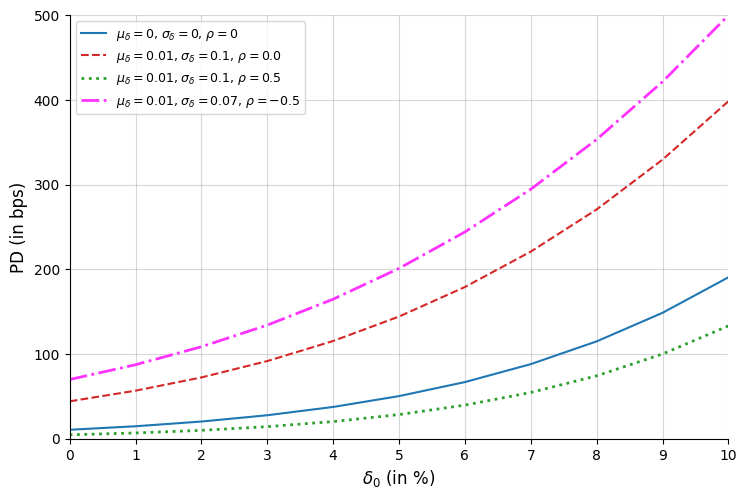

In [6]:
A0, mu_A, sigma_A, D, r, T = 13, 0.05, 0.10, 10, 0.05, 1
delta0_grid = np.arange(0, 0.1001, 0.01)

scenarios5 = [
    (0, 0, 0, "-", color_blue, 1.5),
    (0.01, 0.10, 0.0, "--", color_red, 1.5),
    (0.01, 0.10, 0.5, ":", color_green, 2.0),
    (0.01, 0.07, -0.5, "-.", color_violet, 2.0),
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for mu_d, sig_d, rho_i, style, c, lw in scenarios5:
    pd_curve = pd_extended_merton_model(A0, D, r, mu_A, delta0_grid, mu_d, sigma_A, sig_d, rho_i, T)
    label = rf"$\mu_\delta={mu_d}$, $\sigma_\delta={sig_d}$, $\rho={rho_i}$"
    ax.plot(100 * delta0_grid, 1e4 * pd_curve, style, color=c, linewidth=lw, label=label)

ax.set_xlabel(r"$\delta_0$ (in %)", fontsize=12)
ax.set_ylabel("PD (in bps)", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 10)
ax.set_xticks(range(0, 11, 1))
ax.set_ylim(0, 500)
ax.set_yticks(range(0, 501, 100))
plt.show()


## 3. Plain-Merton asset-haircut PD sensitivity

An instantaneous asset-value haircut `A_t = (1-xi(t))*A0` applied to a
standard (non-extended) Merton distance-to-default, for a fine 1-10%
haircut table (with the average marginal-PD sensitivity `delta`) and a
coarse 0-25% plot.


Baseline PD (bps): 166.41


,xi_t,PD (bps),PD - PD0 (bps)
0,0.01,180.02,13.61
1,0.02,194.72,28.31
2,0.03,210.59,44.18
3,0.04,227.73,61.32
4,0.05,246.23,79.82
5,0.06,266.18,99.77
6,0.07,287.71,121.30
7,0.08,310.91,144.50
8,0.09,335.93,169.52
9,0.10,362.88,196.47


Average marginal PD sensitivity: 16.4288 bps per 1% haircut


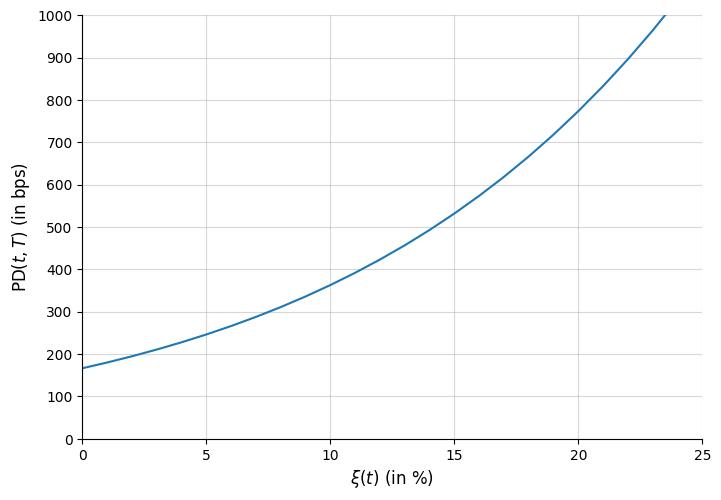

In [7]:
A0, mu_A, sigma_A, D, T = 25, 0.05, 0.10, 20, 10

DD0 = (np.log(A0 / D) + (mu_A - 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
PD0 = norm.cdf(-DD0)
print(f"Baseline PD (bps): {1e4 * PD0:.2f}")

xi_t = np.arange(0.01, 0.1001, 0.01)
A_t = (1 - xi_t) * A0
DD1 = (np.log(A_t / D) + (mu_A - 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
PD1 = norm.cdf(-DD1)
table6 = pd.DataFrame({"xi_t": xi_t, "PD (bps)": 1e4 * PD1, "PD - PD0 (bps)": 1e4 * (PD1 - PD0)})
display(table6.round(2))

delta_sens = np.mean(1e4 * (PD1 - PD0) / (1e2 * xi_t))
print(f"Average marginal PD sensitivity: {delta_sens:.4f} bps per 1% haircut")

xi_t_plot = np.arange(0, 0.2501, 0.01)
A_t_plot = (1 - xi_t_plot) * A0
DD_plot = (np.log(A_t_plot / D) + (mu_A - 0.5 * sigma_A**2) * T) / (sigma_A * np.sqrt(T))
PD_plot = norm.cdf(-DD_plot)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(100 * xi_t_plot, 1e4 * PD_plot, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel(r"$\xi(t)$ (in %)", fontsize=12)
ax.set_ylabel(r"$\mathrm{PD}(t,T)$ (in bps)", fontsize=12)
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 25)
ax.set_xticks(range(0, 26, 5))
ax.set_ylim(0, 1000)
ax.set_yticks(range(0, 1001, 100))
plt.show()


## 4. Implied drift adjustment for a PD-preserving haircut

The drift adjustment `Delta mu_A*(t)` that reproduces a given asset-value
haircut `xi(t)` when applied multiplicatively over the horizon
(`exp(-Delta_mu*T) = 1-xi(t)`, i.e. `Delta_mu_A = -ln(1-xi)/T`), compared
against its first-order (small-`xi`) approximation `xi/T`, for two
maturities. The corresponding distance-to-default/PD-under-haircut
quantities aren't needed for this comparison, so only the two closed
forms and the `xi/T` approximation are computed here.


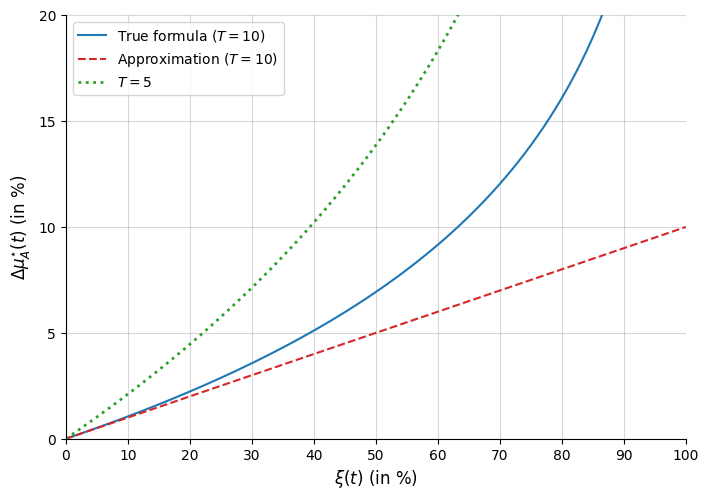

In [8]:
T5, T10 = 5, 10
xi_t7 = np.arange(0, 1.001, 0.01)

with np.errstate(divide="ignore"):
    # xi_t=1.0 (100% haircut) gives log(0) = -inf
    Delta_mu_A_5 = -(1 / T5) * np.log(1 - xi_t7)
    Delta_mu_A_10 = -(1 / T10) * np.log(1 - xi_t7)
approx_10 = xi_t7 / T10

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(100 * xi_t7, 100 * Delta_mu_A_10, "-", color=color_blue, linewidth=1.5, label="True formula ($T=10$)")
ax.plot(100 * xi_t7, 100 * approx_10, "--", color=color_red, linewidth=1.5, label="Approximation ($T=10$)")
ax.plot(100 * xi_t7, 100 * Delta_mu_A_5, ":", color=color_green, linewidth=2.0, label="$T=5$")

ax.set_xlabel(r"$\xi(t)$ (in %)", fontsize=12)
ax.set_ylabel(r"$\Delta \mu_A^{\star}(t)$ (in %)", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
plt.show()
